A carregar base de Treino...
Found 1300 files belonging to 2 classes.
Using 1040 files for training.

A carregar base de Validação...
Found 1300 files belonging to 2 classes.
Using 260 files for validation.

Classes identificadas: ['def_front', 'ok_front']


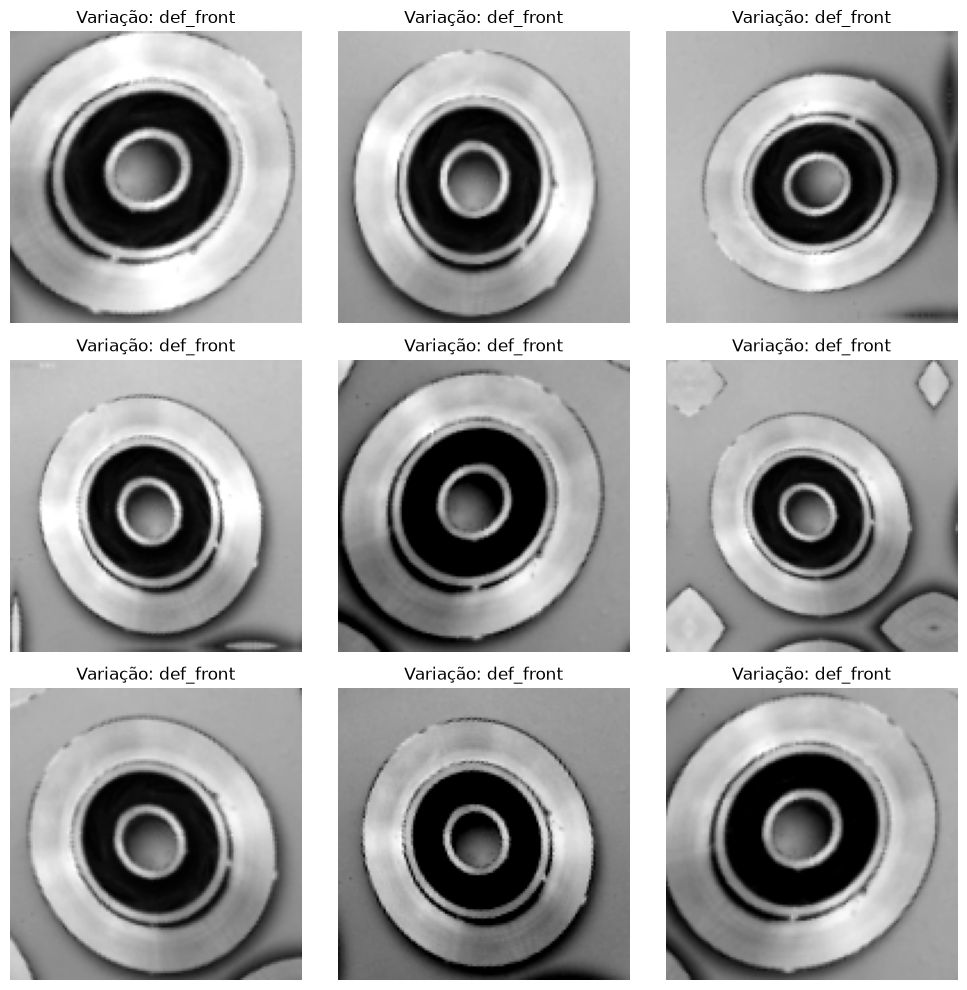

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Definir o diretório com as imagens
# Utilizando a diretoria das imagens de 512x512 que validámos na sprint anterior.
# Esta pasta deve conter as subpastas 'def_front' e 'ok_front'.
dataset_dir = '../data/casting_512x512/' 

# Parâmetros da Rede
BATCH_SIZE = 32
IMG_SIZE = (128, 128) # Reduzimos o tamanho matricial para treinar mais rapidamente em CPU local

# 2. Carregar o Dataset de Treino (80%)
print("A carregar base de Treino...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale" # Trabalharemos a 1 canal (escala de cinza)
)

# 3. Carregar o Dataset de Validação (20%)
print("\nA carregar base de Validação...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

class_names = train_dataset.class_names
print(f"\nClasses identificadas: {class_names}")

# 4. Pipeline de Data Augmentation
# Simula a peça a cair na esteira de diferentes ângulos e sob diferentes condições de luz
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomBrightness(factor=0.2),
])

# 5. Prova Visual do Augmentation
# Pega na primeira imagem do primeiro lote e gera 9 variações dinâmicas
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    image = images[0]
    label = labels[0]
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(image, 0))
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8").squeeze(), cmap='gray')
        plt.title(f"Variação: {class_names[label]}")
        plt.axis("off")
    break

plt.tight_layout()
plt.show()

In [5]:
from tensorflow.keras import layers, models

# 1. Construção da Arquitetura CNN
model = models.Sequential([
    # Incluímos o Data Augmentation definido anteriormente
    data_augmentation,
    
    # Normalização dos píxeis (de 0-255 para 0-1) para facilitar a convergência
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
    
    # Bloco Convolucional 1 (Extração de características básicas, ex: bordas)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco Convolucional 2 (Padrões mais complexos, ex: texturas da trinca)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Bloco Convolucional 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Transição Matricial
    layers.Flatten(),
    
    # Camada Densa para Classificação
    layers.Dense(64, activation='relu'),
    
    # Camada de Saída (1 neurónio com Sigmoid para decisão binária: OK vs Defeito)
    layers.Dense(1, activation='sigmoid')
])

# 2. Compilação do Modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Resumo da estrutura da rede neural
model.summary()

# 3. Treino do Modelo
# Vamos definir 10 épocas. O histórico ficará guardado na variável 'history'
EPOCHS = 10
print(f"\nA iniciar o treino por {EPOCHS} épocas...")

history = model.fit(
  train_dataset,
  validation_data=val_dataset,
  epochs=EPOCHS
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (1, 128, 128, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (1, 128, 128, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 126, 126, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (1, 63, 63, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 61, 61, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (1, 30, 30, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 28, 28, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (1, 14, 14, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (1, 12544)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 64)                │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 858,689 (3.28 MB)

 Trainable params: 858,689 (3.28 MB)

 Non-trainable params: 0 (0.00 B)


A iniciar o treino por 10 épocas...
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.6077 - loss: 0.6871 - val_accuracy: 0.5731 - val_loss: 0.6594
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - accuracy: 0.6077 - loss: 0.6274 - val_accuracy: 0.5731 - val_loss: 0.6097
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.6413 - loss: 0.6091 - val_accuracy: 0.6769 - val_loss: 0.6013
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.6904 - loss: 0.5969 - val_accuracy: 0.6962 - val_loss: 0.6151
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - accuracy: 0.7029 - loss: 0.5754 - val_accuracy: 0.7038 - val_loss: 0.5969
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.7192 - loss: 0.5629 - val_accuracy: 0.7462 - val_loss: 0.5629
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - accuracy: 0.7337 - loss: 0.5364 - val_accuracy: 0.7385 - val_loss: 0.5512
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - accuracy: 0.7

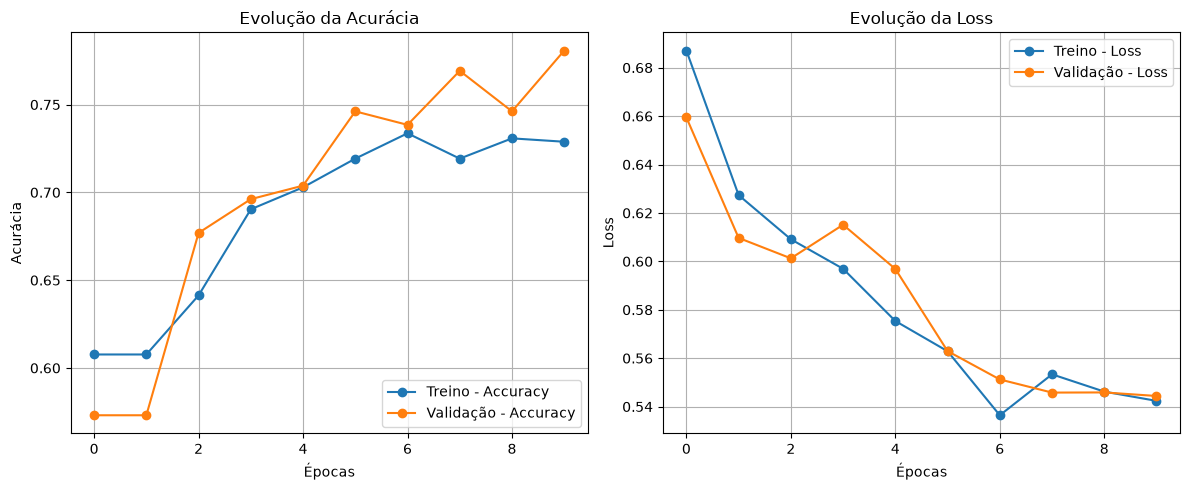

In [6]:
import matplotlib.pyplot as plt

# 1. Extrair os dados do histórico
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

# 2. Criar a figura com dois gráficos
plt.figure(figsize=(12, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Treino - Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validação - Accuracy', marker='o')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfico de Loss (Perda)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Treino - Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validação - Loss', marker='o')
plt.title('Evolução da Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()